# Analyse der Preisdynamik

Dieses Notebook untersucht die beobachteten Veränderungen des zum jeweiligen Abruf aktuell auf der Produktseite angezeigten Preises (`current_price`) bei **Tennistown**, **Tennis-Heine** und **Tennis-Point** im Erhebungszeitraum vom 14.06.2026 bis zum 17.07.2026.

Der gegebenenfalls ausgewiesene Streichpreis (`regular_price`) und die unverbindliche Preisempfehlung (`msrp_price`) werden in diesem Notebook nicht untersucht.

Im Mittelpunkt stehen:

- der Umfang beobachteter Preisänderungen und deren Verteilung auf die Produktvarianten
- Unterschiede in der Preisänderungsrate nach Händler und Produktkategorie
- die Richtung und Stärke der beobachteten Preisänderungen
- mögliche zeitliche Muster zwischen den beiden täglichen Abrufen und den Wochentagen
- ausgewählte Produktvarianten mit auffälligen Preisverläufen

Die Analyse wird bewusst auf wenige aggregierte Kennzahlen und ausgewählte Fallbeispiele begrenzt. Eine händlerübergreifende Untersuchung möglicher Wettbewerbsreaktionen erfolgt in einem weiteren Notebook.

Produktvarianten werden innerhalb eines Händlers über die Kombination aus `product_url_key` und `reference_variant` verfolgt. Eine normalisierte GTIN ist für die händlerinterne Analyse der Preisdynamik daher nicht erforderlich.

> **Umgang mit fehlenden Beobachtungen:** Es werden ausschließlich tatsächlich vorhandene Produktbeobachtungen ausgewertet. Fehlende Beobachtungen werden nicht ergänzt und vorhandene Preise werden nicht künstlich fortgeschrieben. Liegt zwischen zwei Beobachtungen eine Erfassungslücke, kann eine festgestellte Preisdifferenz nicht eindeutig einem bestimmten Abrufzeitpunkt zugeordnet werden. Zeitliche Auswertungen werden deshalb später auf unmittelbar vergleichbare Beobachtungspaare beschränkt.

> **Berücksichtigung der Verfügbarkeit:** Die Auswertung des `current_price` erfolgt unabhängig vom Verfügbarkeitsstatus. Auch bei einer nicht verfügbaren Produktvariante kann auf der Produktseite weiterhin ein Preis ausgegeben und während des Scraping-Vorgangs erfasst werden. Dieser wird als beobachtete Preisangabe der Webseite ausgewertet, jedoch nicht als Nachweis eines zu diesem Zeitpunkt tatsächlich kaufbaren Angebots interpretiert.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Einheitliches Erscheinungsbild für alle Visualisierungen festlegen
sns.set_theme(style='whitegrid', context='notebook')

In [2]:
# --- PFAD-KONFIGURATION ---

# Verzeichnis mit dem aufbereiteten Datenbestand
data_processed_dir = '../data/processed'

# Dateiname der aufbereiteten Datentabelle
processed_file_name = 'tennis_data_prepared.csv'

# Vollständigen Dateipfad erzeugen
processed_file_path = os.path.join(data_processed_dir, processed_file_name)

## Aufbereiteten Datenbestand einlesen

Die in `02_data_preparation` erzeugte Datei `tennis_data_prepared.csv` wird als Grundlage der Preisanalyse eingelesen.

Die Identifikatoren `product_url_key`, `ean` und `gtin_normalized` werden ausdrücklich als Zeichenfolgen geladen. Dadurch bleiben ihre Formate und mögliche führende Nullen erhalten. `timestamp` und `run_date` werden als Datumswerte eingelesen, damit die Beobachtungen später chronologisch geordnet und zeitlich ausgewertet werden können.

In [3]:
if not os.path.exists(processed_file_path):
    raise FileNotFoundError(f'Die Datei "{processed_file_path}" wurde nicht gefunden.')

df_tennis_data = pd.read_csv(
    processed_file_path,
    encoding='utf-8',
    dtype={
        'product_url_key': 'string',
        'ean': 'string',
        'gtin_normalized': 'string'
    },
    parse_dates=[
        'timestamp',
        'run_date'
    ]
)

print('--- AUFBEREITETER DATENBESTAND EINGELESEN ---')
print(f'Beobachtungen: {len(df_tennis_data)}')
print(f'Spalten: {len(df_tennis_data.columns)}')
print(f'Erhebungszeitraum: {df_tennis_data["timestamp"].min():%d.%m.%Y} bis {df_tennis_data["timestamp"].max():%d.%m.%Y}')

--- AUFBEREITETER DATENBESTAND EINGELESEN ---
Beobachtungen: 87609
Spalten: 19
Erhebungszeitraum: 14.06.2026 bis 17.07.2026


In [4]:
# Beispielhafte Ausgabe der ersten Produktbeobachtungen
display(df_tennis_data.head())

,retailer,timestamp,run_date,run,source_file,category,gender,brand,name,reference_variant,product_url_key,ean,gtin_normalized,current_price,regular_price,msrp_price,currency,availability,url
0,Tennistown,2026-06-14 10:13:49,2026-06-14,run1,tennistown_2026-06-14_run1.csv,rackets,unisex,Head,Head Tennisschläger Boom MP Neon 100in/295g/Tu...,L2,95421,0198772103576,00198772103576,161.96,179.95,260.00,€,in_stock,https://www.tennistown.de/product_info.php?cPa...
1,Tennistown,2026-06-14 10:13:49,2026-06-14,run1,tennistown_2026-06-14_run1.csv,rackets,unisex,Head,Head Tennisschläger Boom MP Neon 100in/295g/Tu...,L3,95421,0198772103583,00198772103583,161.96,179.95,260.00,€,in_stock,https://www.tennistown.de/product_info.php?cPa...
2,Tennistown,2026-06-14 10:13:54,2026-06-14,run1,tennistown_2026-06-14_run1.csv,rackets,unisex,Head,Head Tennisschläger Gravity Tour 100in/305g/Tu...,L2,69457,<NA>,<NA>,151.20,168.00,280.00,€,out_of_stock,https://www.tennistown.de/product_info.php?cPa...
3,Tennistown,2026-06-14 10:13:54,2026-06-14,run1,tennistown_2026-06-14_run1.csv,rackets,unisex,Head,Head Tennisschläger Gravity Tour 100in/305g/Tu...,L3,69457,<NA>,<NA>,151.20,168.00,280.00,€,out_of_stock,https://www.tennistown.de/product_info.php?cPa...
4,Tennistown,2026-06-14 10:13:57,2026-06-14,run1,tennistown_2026-06-14_run1.csv,rackets,unisex,Yonex,Yonex Tennisschläger EZone (8th Gen.) 98in/305...,L2,87664,<NA>,<NA>,244.90,NaN,279.95,€,out_of_stock,https://www.tennistown.de/product_info.php?cPa...


## Umfang der Datenbasis darstellen

Zunächst wird der Umfang der verfügbaren Daten je Händler anhand der Anzahl der Produktbeobachtungen und unterschiedlichen Produktvarianten zusammengefasst. Eine Produktbeobachtung entspricht dabei einer erfassten Produktvariante bei einem bestimmten Abruf.

In [5]:
# --- DATENBASIS DER PREISANALYSE ZUSAMMENFASSEN ---

# Einheitliche Reihenfolge der Händler für alle Ergebnistabellen festlegen
retailer_order = ['Tennistown', 'Tennis-Heine', 'Tennis-Point']

# Anzahl unterschiedlicher Produktvarianten je Händler bestimmen
product_variant_counts_by_retailer = (
    df_tennis_data[[
        'retailer',
        'product_url_key',
        'reference_variant'
    ]]
    .drop_duplicates()
    .groupby('retailer', sort=False)
    .size()
)

# Beobachtungsumfang je Händler zusammenfassen
df_price_data_overview = (
    df_tennis_data
    .groupby('retailer', sort=False)
    .agg(Observations=('current_price', 'size'))
    .reset_index()
    .rename(columns={'retailer': 'Retailer'})
)

# Anzahl unterschiedlicher Produktvarianten ergänzen
df_price_data_overview['Product variants'] = (
    df_price_data_overview['Retailer']
    .map(product_variant_counts_by_retailer)
)

# Händler in der festgelegten Reihenfolge anordnen
df_price_data_overview = (
    df_price_data_overview
    .set_index('Retailer')
    .reindex(retailer_order)
    .reset_index()
)

print('--- DATENBASIS DER PREISANALYSE ---')
print('Zeigt den Umfang der vorhandenen Preisbeobachtungen und Produktvarianten je Händler an.\n')

display(df_price_data_overview)

--- DATENBASIS DER PREISANALYSE ---
Zeigt den Umfang der vorhandenen Preisbeobachtungen und Produktvarianten je Händler an.



,Retailer,Observations,Product variants
0,Tennistown,39394,723
1,Tennis-Heine,27458,491
2,Tennis-Point,20757,686


## Vergleichbare Preisbeobachtungen bilden

Für jede Produktvariante werden die Beobachtungen zunächst nach Abrufdatum und Abrufkennung chronologisch geordnet. Anschließend wird der zum jeweiligen Abruf aktuell angezeigte Preis (`current_price`) dem entsprechenden Preis der vorherigen Beobachtung derselben Produktvariante beim gleichen Händler gegenübergestellt.

Für die Berechnung einer Preisänderung werden ausschließlich Beobachtungen aus direkt aufeinanderfolgenden geplanten Abrufen verwendet. Dies betrifft:

- den Vergleich zwischen `run1` und `run2` desselben Abruftages
- den Vergleich zwischen `run2` eines Abruftages und `run1` des unmittelbar folgenden Tages

`run1` bezeichnet den planmäßig morgens und `run2` den planmäßig abends vorgesehenen Abruf. Ein unmittelbar vergleichbares Beobachtungspaar besteht aus zwei Beobachtungen derselben Produktvariante beim gleichen Händler, die aus zwei direkt aufeinanderfolgenden geplanten Abrufen stammen. Fehlt eine der erforderlichen Beobachtungen, wird kein Vergleichspaar gebildet.

Dadurch werden Erfassungslücken weder aufgefüllt noch fälschlich als unveränderter Preis interpretiert. Dies betrifft insbesondere Tennis-Point, dessen vorhandene Produktbeobachtungen weiterhin berücksichtigt werden, sofern für die jeweilige Produktvariante zwei unmittelbar aufeinanderfolgende Beobachtungen vorliegen.

In [6]:
# --- PREISBEOBACHTUNGEN CHRONOLOGISCH VORBEREITEN ---

# Kopie des aufbereiteten Datenbestands für die Preisanalyse erstellen
df_price_history = df_tennis_data.copy()

# Reihenfolge der beiden täglichen Abrufe festlegen
df_price_history['run_order'] = df_price_history['run'].map({'run1': 1, 'run2': 2})

# Spalten zur händlerinternen Bestimmung einer Produktvariante festlegen
product_variant_columns = ['retailer', 'product_url_key', 'reference_variant']

# Beobachtungen je Produktvariante nach den geplanten Abrufen ordnen
df_price_history = (
    df_price_history
    .sort_values(product_variant_columns + ['run_date', 'run_order'])
    .reset_index(drop=True)
)

# Gruppierung für die Berechnung innerhalb derselben Produktvariante vorbereiten
price_history_groups = df_price_history.groupby(product_variant_columns, sort=False)

# Preis, Abrufdatum, Abrufkennung und Erfassungszeitpunkt der jeweils vorherigen Beobachtung ergänzen
df_price_history['previous_price'] = price_history_groups['current_price'].shift(1)
df_price_history['previous_run_date'] = price_history_groups['run_date'].shift(1)
df_price_history['previous_run'] = price_history_groups['run'].shift(1)
df_price_history['previous_timestamp'] = price_history_groups['timestamp'].shift(1)


In [7]:
# --- UNMITTELBAR VERGLEICHBARE BEOBACHTUNGSPAARE BESTIMMEN ---

# Vergleich von run1 und run2 desselben Abruftages kennzeichnen
is_same_day_pair = (
    df_price_history['previous_run'].eq('run1')
    & df_price_history['run'].eq('run2')
    & df_price_history['previous_run_date'].eq(df_price_history['run_date'])
)

# Vergleich von run2 und run1 des unmittelbar folgenden Tages kennzeichnen
is_next_day_pair = (
    df_price_history['previous_run'].eq('run2')
    & df_price_history['run'].eq('run1')
    & df_price_history['run_date'].eq(df_price_history['previous_run_date'] + pd.Timedelta(days=1))
)

# Art des zeitlichen Vergleichs festhalten
df_price_history['comparison_interval'] = pd.NA

df_price_history.loc[is_same_day_pair, 'comparison_interval'] = 'run1 to run2'
df_price_history.loc[is_next_day_pair, 'comparison_interval'] = 'run2 to next run1'

# Nur unmittelbar vergleichbare Beobachtungspaare übernehmen
comparable_pair_mask = is_same_day_pair | is_next_day_pair

df_price_pairs = (
    df_price_history
    .loc[comparable_pair_mask]
    .copy()
    .reset_index(drop=True)
)

## Umfang der beobachteten Preisänderungen auswerten

Für jedes unmittelbar vergleichbare Beobachtungspaar wird die absolute und prozentuale Veränderung des `current_price` berechnet. Anschließend wird je Händler zusammengefasst, wie viele vergleichbare Beobachtungspaare vorliegen und bei wie vielen davon eine Preiserhöhung beziehungsweise Preissenkung festgestellt wird.

Eine Preisänderung liegt vor, wenn sich der angezeigte `current_price` zwischen zwei unmittelbar vergleichbaren Beobachtungen derselben Produktvariante unterscheidet. Die Preisänderungsrate bezeichnet den Anteil dieser Vergleichspaare, bei denen eine solche Veränderung festgestellt wird.

**Preisänderungsrate (%) = (Beobachtungspaare mit Preisänderung / vergleichbare Beobachtungspaare) × 100**

Durch die Berücksichtigung der Anzahl vergleichbarer Beobachtungspaare können Händler, Produktkategorien und zeitliche Gruppen mit unterschiedlich großem Beobachtungsumfang besser gegenübergestellt werden. Die Preisänderungsrate sagt jedoch weder aus, wie stark sich die Preise verändert haben, noch wie viele unterschiedliche Produktvarianten betroffen sind.

In [8]:
# --- PREISÄNDERUNGEN BERECHNEN ---

# Absolute Preisänderung gegenüber der vorherigen Beobachtung berechnen
df_price_pairs['price_change_eur'] = (df_price_pairs['current_price'] - df_price_pairs['previous_price']).round(2)

# Prozentuale Preisänderung gegenüber dem vorherigen Preis für spätere Auswertungen berechnen
df_price_pairs['price_change_pct'] = (df_price_pairs['price_change_eur'] / df_price_pairs['previous_price'] * 100).round(2)

# Beobachtungspaare mit verändertem Preis kennzeichnen
df_price_pairs['price_changed'] = df_price_pairs['price_change_eur'].ne(0)

# Richtung der Preisveränderung festlegen
df_price_pairs['price_direction'] = 'unchanged'

df_price_pairs.loc[df_price_pairs['price_change_eur'].gt(0), 'price_direction'] = 'increase'
df_price_pairs.loc[df_price_pairs['price_change_eur'].lt(0), 'price_direction'] = 'decrease'

In [9]:
# --- PREISÄNDERUNGEN JE HÄNDLER ZUSAMMENFASSEN ---
df_price_change_overview = (
    df_price_pairs
    .groupby('retailer', sort=False)
    .agg(
        Comparable_pairs=('comparison_interval', 'size'),                                   # Anzahl aller unmittelbar vergleichbaren Beobachtungspaare bestimmen
        Price_changes=('price_changed', 'sum'),                                             # Anzahl der Beobachtungspaare mit einer Preisänderung bestimmen
        Price_increases=('price_direction', lambda values: values.eq('increase').sum()),    # Beobachtungspaare mit einer Preiserhöhung zählen
        Price_decreases=('price_direction', lambda values: values.eq('decrease').sum())     # Beobachtungspaare mit einer Preissenkung zählen
    )
    .reset_index()
    .rename(columns={
        'retailer': 'Retailer',
        'Comparable_pairs': 'Comparable pairs',
        'Price_changes': 'Price changes',
        'Price_increases': 'Price increases',
        'Price_decreases': 'Price decreases'
    })
)

# Anteil der Beobachtungspaare mit verändertem Preis berechnen
df_price_change_overview['Price change rate (%)'] = (df_price_change_overview['Price changes'] / df_price_change_overview['Comparable pairs'] * 100).round(2)

# Gewünschte Spaltenreihenfolge festlegen
df_price_change_overview = df_price_change_overview[[
    'Retailer',
    'Comparable pairs',
    'Price changes',
    'Price change rate (%)',
    'Price increases',
    'Price decreases'
]]

# Händler in der festgelegten Reihenfolge anordnen
df_price_change_overview = (
    df_price_change_overview
    .set_index('Retailer')
    .reindex(retailer_order)
    .reset_index()
)

print('--- UMFANG DER BEOBACHTETEN PREISÄNDERUNGEN ---')
print('Zeigt vergleichbare Beobachtungspaare und festgestellte Preisänderungen je Händler an.\n')

display(df_price_change_overview)

--- UMFANG DER BEOBACHTETEN PREISÄNDERUNGEN ---
Zeigt vergleichbare Beobachtungspaare und festgestellte Preisänderungen je Händler an.



,Retailer,Comparable pairs,Price changes,Price change rate (%),Price increases,Price decreases
0,Tennistown,33144,3740,11.28,2103,1637
1,Tennis-Heine,23119,24,0.10,6,18
2,Tennis-Point,12719,874,6.87,369,505


Bei Tennis-Heine werden 23.119 unmittelbar vergleichbare Beobachtungspaare gebildet. Lediglich bei 24 dieser Paare verändert sich der angezeigte Preis, was einer Preisänderungsrate von 0,10 % entspricht. Die Preise bleiben bei diesem Händler im Untersuchungszeitraum somit weitgehend stabil. Von den wenigen festgestellten Änderungen entfallen 6 auf Preiserhöhungen und 18 auf Preissenkungen.

Bei Tennis-Point werden innerhalb von 12.719 vergleichbaren Beobachtungspaaren insgesamt 874 Preisänderungen festgestellt. Die Preisänderungsrate liegt bei 6,87 %. Dabei treten mit 505 Preissenkungen häufiger Preisreduzierungen als die 369 beobachteten Preiserhöhungen auf. Die Ergebnisse beziehen sich ausschließlich auf Produktvarianten, für die Beobachtungen aus zwei direkt aufeinanderfolgenden Abrufen vorliegen. Die gegenüber den anderen Händlern geringere Anzahl vergleichbarer Beobachtungspaare steht unter anderem mit den vollständig und teilweise unvollständigen Tennis-Point-Abrufen in Zusammenhang.

Tennistown weist mit 3.740 Preisänderungen innerhalb von 33.144 vergleichbaren Beobachtungspaaren die höchste beobachtete Preisänderungsrate auf. Bei 11,28 % der Paare verändert sich der angezeigte Preis. Im Unterschied zu Tennis-Point überwiegen bei Tennistown die Preiserhöhungen: Den 2.103 Erhöhungen stehen 1.637 Preissenkungen gegenüber.

Die Ergebnisse zeigen damit deutliche Unterschiede in der beobachteten Preisdynamik. Während die angezeigten Preise bei Tennis-Heine nahezu konstant bleiben, werden bei Tennis-Point und insbesondere bei Tennistown wesentlich häufiger Preisänderungen beobachtet. Eine Preisänderung bezeichnet dabei jeweils den Übergang zwischen zwei Beobachtungen. Dieselbe Produktvariante kann deshalb mehrfach in die Anzahl der Preisänderungen eingehen. Über die Stärke der jeweiligen Preisänderungen oder die Anzahl unterschiedlicher betroffener Produktvarianten trifft diese Übersicht noch keine Aussage.

> **Hinweis zur Interpretation:**
> Die Preisänderungsraten beziehen sich ausschließlich auf die tatsächlich vorhandenen, unmittelbar vergleichbaren Beobachtungspaare. Produktbeobachtungen, die aufgrund vollständig oder teilweise fehlgeschlagener Abrufe nicht erfasst wurden, gehen weder in die Anzahl der Preisänderungen noch in die Anzahl der Vergleichspaare ein.
>
> Dies betrifft insbesondere Tennis-Point. Für die nicht erfassten Produktbeobachtungen kann nicht festgestellt werden, ob die Preise unverändert blieben, erhöht oder gesenkt wurden. Die berechneten Preisänderungsraten beschreiben daher nur den jeweils beobachtbaren Ausschnitt der Händlerdaten und können nicht uneingeschränkt auf das vollständige Sortiment oder den gesamten Erhebungszeitraum übertragen werden. Der Vergleich zwischen den Händlern ist entsprechend als deskriptiver Vergleich der vorhandenen Beobachtungspaare zu verstehen.
>
> Eine theoretisch maximal mögliche Anzahl vergleichbarer Beobachtungspaare wird nicht ausgewiesen. Für fehlende Paare kann nicht eindeutig unterschieden werden, ob sie auf vollständig oder teilweise fehlgeschlagene Abrufe, technische Erfassungslücken oder tatsächliche Veränderungen des Händlersortiments zurückzuführen sind.
>
> Diese Einschränkung gilt ebenfalls für alle folgenden Auswertungen, die auf den unmittelbar vergleichbaren Beobachtungspaaren basieren.

## Produktvarianten mit Preisänderungen bestimmen

Die bisherige Übersicht betrachtet jedes unmittelbar aufeinanderfolgende Beobachtungspaar separat. Eine Produktvariante kann daher mehrfach als Preisänderung berücksichtigt werden, wenn ihr Preis im Erhebungszeitraum wiederholt erhöht oder gesenkt wurde.

Im folgenden Schritt wird jede Produktvariante nur einmal betrachtet. Die Ergebnistabelle zeigt je Händler zunächst die Gesamtzahl der vorhandenen Produktvarianten. Anschließend wird ausgewertet, für wie viele davon mindestens ein vergleichbares Beobachtungspaar vorliegt und bei wie vielen dieser vergleichbaren Varianten mindestens eine Preisänderung festgestellt wird.

Der Anteil vergleichbarer Produktvarianten zeigt, für welchen Teil der vorhandenen Produktvarianten mindestens ein direkter Preisvergleich möglich ist. Der Anteil betroffener Produktvarianten zeigt anschließend, wie breit sich die beobachteten Preisänderungen über die vergleichbaren Produktvarianten des jeweiligen Händlers verteilen.

In [10]:
# --- PREISÄNDERUNGEN JE PRODUKTVARIANTE ZUSAMMENFASSEN ---
df_product_variant_price_change_summary = (
    df_price_pairs
    .groupby(product_variant_columns, sort=False
    )
    .agg(
        # Kennzeichnen, ob bei der Produktvariante mindestens eine Preisänderung vorliegt
        Has_price_change=('price_changed', 'any'),
    )
    .reset_index()
)

In [11]:
# --- VERGLEICHBARE UND BETROFFENE PRODUKTVARIANTEN JE HÄNDLER ZUSAMMENFASSEN ---
df_product_variant_change_overview = (
    df_product_variant_price_change_summary
    .groupby('retailer', sort=False)
    .agg(
        Comparable_product_variants=('Has_price_change', 'size'),           # Alle Produktvarianten mit mindestens einem Vergleichspaar zählen
        Product_variants_with_price_change=('Has_price_change', 'sum')      # Produktvarianten mit mindestens einer Preisänderung zählen
    )
    .reset_index()
    .rename(columns={
        'retailer': 'Retailer',
        'Comparable_product_variants': 'Comparable product variants',
        'Product_variants_with_price_change': 'Product variants with price change'
    })
)

# Gesamtzahl aller vorhandenen Produktvarianten ergänzen
df_product_variant_change_overview['Product variants'] = df_product_variant_change_overview['Retailer'].map(product_variant_counts_by_retailer)

# Anteil der Produktvarianten mit mindestens einem Vergleichspaar berechnen
df_product_variant_change_overview['Comparable product variants (%)'] = (
    df_product_variant_change_overview['Comparable product variants']
    / df_product_variant_change_overview['Product variants']
    * 100
).round(1)

# Anteil der Produktvarianten mit mindestens einer Preisänderung berechnen
df_product_variant_change_overview['Affected product variants (%)'] = (
    df_product_variant_change_overview['Product variants with price change']
    / df_product_variant_change_overview['Comparable product variants']
    * 100
).round(1)

# Gewünschte Spaltenreihenfolge festlegen
df_product_variant_change_overview = df_product_variant_change_overview[[
    'Retailer',
    'Product variants',
    'Comparable product variants',
    'Comparable product variants (%)',
    'Product variants with price change',
    'Affected product variants (%)'
]]

# Händler in der festgelegten Reihenfolge anordnen
df_product_variant_change_overview = (
    df_product_variant_change_overview
    .set_index('Retailer')
    .reindex(retailer_order)
    .reset_index()
)

print('--- PRODUKTVARIANTEN MIT PREISÄNDERUNGEN ---')
print('Zeigt den Anteil vergleichbarer Produktvarianten und die davon von Preisänderungen betroffenen Varianten je Händler an.\n')

display(df_product_variant_change_overview)

--- PRODUKTVARIANTEN MIT PREISÄNDERUNGEN ---
Zeigt den Anteil vergleichbarer Produktvarianten und die davon von Preisänderungen betroffenen Varianten je Händler an.



,Retailer,Product variants,Comparable product variants,Comparable product variants (%),Product variants with price change,Affected product variants (%)
0,Tennistown,723,721,99.7,471,65.3
1,Tennis-Heine,491,491,100.0,24,4.9
2,Tennis-Point,686,651,94.9,399,61.3


Bei Tennistown liegt für 721 der insgesamt 723 Produktvarianten mindestens ein unmittelbar vergleichbares Beobachtungspaar vor. Dies entspricht einem Anteil von 99,7 %. Bei 471 dieser vergleichbaren Produktvarianten wird im Erhebungszeitraum mindestens eine Preisänderung festgestellt. Mit 65,3 % ist somit ein großer Teil der vergleichbaren Tennistown-Produktvarianten von Preisänderungen betroffen.

Bei Tennis-Heine liegt für alle 491 Produktvarianten mindestens ein unmittelbar vergleichbares Beobachtungspaar vor. Lediglich bei 24 Varianten wird mindestens eine Preisänderung beobachtet. Der Anteil betroffener Produktvarianten beträgt damit 4,9 % und bestätigt das bereits zuvor festgestellte weitgehend stabile Preisniveau dieses Händlers.

Bei Tennis-Point liegt für 651 der insgesamt 686 Produktvarianten mindestens ein unmittelbar vergleichbares Beobachtungspaar vor. Dies entspricht einem Anteil von 94,9 %. Bei 399 vergleichbaren Varianten und damit bei 61,3 % wird mindestens eine Preisänderung festgestellt. Trotz der vollständig ausgefallenen und teilweise unvollständigen Abrufe kann somit für einen großen Teil der erfassten Produktvarianten grundsätzlich mindestens ein direkter Preisvergleich durchgeführt werden.

Die zuvor berechnete Preisänderungsrate bezieht sich auf einzelne Beobachtungspaare. Bei Tennistown beispielsweise verändert sich der Preis bei 11,28 % dieser Paare. Der Anteil betroffener Produktvarianten betrachtet dagegen unterschiedliche Produktvarianten: Bei 65,3 % der vergleichbaren Tennistown-Varianten wird während des gesamten Erhebungszeitraums mindestens einmal eine Preisänderung festgestellt.

Der Anteil vergleichbarer Produktvarianten beschreibt, für wie viele aller vorhandenen Produktvarianten mindestens ein direktes Vergleichspaar vorliegt. Er bedeutet nicht, dass diese Varianten über den gesamten Erhebungszeitraum lückenlos beobachtet wurden.









## Preisänderungen nach Produktkategorie vergleichen

Die bisherige Auswertung zeigt den Umfang der Preisänderungen auf Händlerebene. Im folgenden Schritt wird zusätzlich zwischen Tennisschlägern, Tennisschuhen und Tennissaiten unterschieden.

Für jeden Händler und jede Produktkategorie werden die Anzahl unmittelbar vergleichbarer Beobachtungspaare sowie die darin festgestellten Preisänderungen zusammengefasst. Da sich der Umfang der Kategorien unterscheidet, wird zusätzlich die Preisänderungsrate berechnet. Sie gibt an, bei welchem Anteil der vergleichbaren Beobachtungspaare innerhalb der jeweiligen Kategorie eine Preisänderung auftritt.

In [12]:
# --- PREISÄNDERUNGEN NACH HÄNDLER UND PRODUKTKATEGORIE ZUSAMMENFASSEN ---
df_price_change_category_overview = (
    df_price_pairs
    .groupby(['retailer', 'category'], sort=False)
    .agg(
        Comparable_pairs=('comparison_interval', 'size'),       # Anzahl unmittelbar vergleichbarer Beobachtungspaare bestimmen
        Price_changes=('price_changed', 'sum')                  # Beobachtungspaare mit einer Preisänderung zählen
    )
    .reset_index()
    .rename(columns={
        'retailer': 'Retailer',
        'category': 'Category',
        'Comparable_pairs': 'Comparable pairs',
        'Price_changes': 'Price changes'
    })
)

# Anteil der Beobachtungspaare mit einer Preisänderung berechnen
df_price_change_category_overview['Price change rate (%)'] = (
    df_price_change_category_overview['Price changes']
    / df_price_change_category_overview['Comparable pairs']
    * 100
).round(2)

# Gewünschte Reihenfolge der Produktkategorien festlegen
category_order = ['rackets', 'shoes', 'strings']

# Händler und Produktkategorien in der festgelegten Reihenfolge anordnen
df_price_change_category_overview['Retailer'] = pd.Categorical(
    df_price_change_category_overview['Retailer'],
    categories=retailer_order,
    ordered=True
)

df_price_change_category_overview['Category'] = pd.Categorical(
    df_price_change_category_overview['Category'],
    categories=category_order,
    ordered=True
)

df_price_change_category_overview = (
    df_price_change_category_overview
    .sort_values(['Retailer', 'Category'])
    .reset_index(drop=True)
)

print('--- PREISÄNDERUNGEN NACH PRODUKTKATEGORIE ---')
print('Zeigt vergleichbare Beobachtungspaare und Preisänderungen je Händler und Produktkategorie an.\n')

display(df_price_change_category_overview)

--- PREISÄNDERUNGEN NACH PRODUKTKATEGORIE ---
Zeigt vergleichbare Beobachtungspaare und Preisänderungen je Händler und Produktkategorie an.



,Retailer,Category,Comparable pairs,Price changes,Price change rate (%)
0,Tennistown,rackets,11588,1630,14.07
1,Tennistown,shoes,17336,1699,9.80
2,Tennistown,strings,4220,411,9.74
3,Tennis-Heine,rackets,17118,24,0.14
4,Tennis-Heine,shoes,4129,0,0.00
5,Tennis-Heine,strings,1872,0,0.00
6,Tennis-Point,rackets,9419,662,7.03
7,Tennis-Point,shoes,1959,170,8.68
8,Tennis-Point,strings,1341,42,3.13


Die Preisänderungsraten werden in einem gruppierten Balkendiagramm gegenübergestellt. Dadurch werden Unterschiede zwischen den Händlern und Produktkategorien unmittelbar sichtbar.

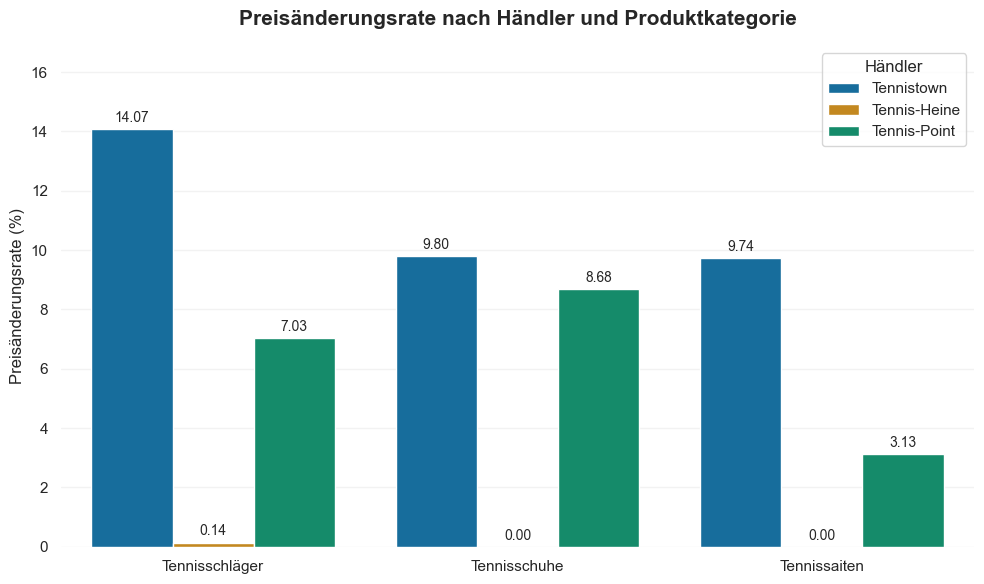

In [13]:
# --- PREISÄNDERUNGSRATEN NACH PRODUKTKATEGORIE VISUALISIEREN ---

# Diagrammfläche vorbereiten
fig, ax = plt.subplots(figsize=(10, 6))

# Gruppiertes Balkendiagramm erzeugen
sns.barplot(
    data=df_price_change_category_overview,
    x='Category',
    y='Price change rate (%)',
    hue='Retailer',
    order=category_order,
    hue_order=retailer_order,
    palette='colorblind',
    errorbar=None,
    ax=ax
)

# Prozentwerte über den Balken anzeigen
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# Deutsche Bezeichnungen für die Produktkategorien verwenden
category_labels = {'rackets': 'Tennisschläger', 'shoes': 'Tennisschuhe', 'strings': 'Tennissaiten'}
ax.set_xticks(range(len(category_order)))
ax.set_xticklabels([category_labels[c] for c in category_order])

# Diagramm beschriften
ax.set_title('Preisänderungsrate nach Händler und Produktkategorie', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Preisänderungsrate (%)')

# Legende und Gitternetz anpassen
ax.legend(title='Händler')
ax.grid(axis='y', alpha=0.25)

# Zusätzlichen Platz für die Werte oberhalb der Balken schaffen
ax.set_ylim(0, df_price_change_category_overview['Price change rate (%)'].max() * 1.2)

# Diagramm abschließend formatieren und anzeigen
sns.despine(ax=ax, left=True, bottom=True)
plt.tight_layout()
plt.show()

Im beobachtbaren Datenbestand weist Tennistown in allen drei Produktkategorien die höchste Preisdynamik auf. Besonders häufig verändern sich die Preise bei Tennisschlägern mit einer Preisänderungsrate von 14,07 %, während Schuhe und Saiten jeweils bei knapp 10 % liegen.

Bei Tennis-Point treten Preisänderungen vor allem bei Schuhen und Schlägern auf, während Saiten deutlich seltener betroffen sind. Tennis-Heine zeigt dagegen in allen Kategorien ein nahezu unverändertes Preisniveau, lediglich bei Schlägern werden vereinzelt Preisänderungen festgestellt.

## Stärke der Preisänderungen auswerten

Die bisherigen Auswertungen zeigen, wie häufig Preisänderungen auftreten und wie viele Produktvarianten davon betroffen sind. Im folgenden Schritt wird die Stärke der festgestellten Preisänderungen betrachtet.

Hierfür werden ausschließlich Beobachtungspaare mit einer tatsächlichen Preisänderung berücksichtigt. Preissteigerungen und Preissenkungen werden als absolute Beträge ausgewertet, damit sich gegenläufige Änderungen nicht gegenseitig aufheben. Als zentrale Kennzahl wird der Median verwendet, da er weniger stark durch einzelne außergewöhnlich große Preisänderungen beeinflusst wird.

In [14]:
# --- PREISÄNDERUNGEN FÜR DIE STÄRKENANALYSE VORBEREITEN ---

# Beobachtungspaare mit einer tatsächlichen Preisänderung auswählen
df_pairs_with_price_change = (
    df_price_pairs
    .loc[df_price_pairs['price_changed']]
    .copy()
)

# Betrag der absoluten und prozentualen Preisänderung berechnen
df_pairs_with_price_change['absolute_price_change_eur'] = df_pairs_with_price_change['price_change_eur'].abs()
df_pairs_with_price_change['absolute_price_change_pct'] = df_pairs_with_price_change['price_change_pct'].abs()

# --- STÄRKE DER PREISÄNDERUNGEN JE HÄNDLER ZUSAMMENFASSEN ---
df_price_change_strength_overview = (
    df_pairs_with_price_change
    .groupby('retailer', sort=False)
    .agg(
        
        Price_changes=('price_changed', 'size'),                                # Anzahl der berücksichtigten Preisänderungen bestimmen
        Median_absolute_change_eur=('absolute_price_change_eur', 'median'),     # Median der absoluten Preisänderungen bestimmen
        Median_absolute_change_pct=('absolute_price_change_pct', 'median'),     # Median der absoluten Preisänderungen in Prozent bestimmen
        Maximum_absolute_change_eur=('absolute_price_change_eur', 'max')        # Größte beobachtete absolute Preisänderung bestimmen
    )
    .reset_index()
    .rename(columns={
        'retailer': 'Retailer',
        'Price_changes': 'Price changes',
        'Median_absolute_change_eur': 'Median absolute change (€)',
        'Median_absolute_change_pct': 'Median absolute change (%)',
        'Maximum_absolute_change_eur': 'Maximum absolute change (€)'
    })
)

# Kennzahlen auf zwei Nachkommastellen runden
df_price_change_strength_overview = (
    df_price_change_strength_overview
    .round({
        'Median absolute change (€)': 2,
        'Median absolute change (%)': 2,
        'Maximum absolute change (€)': 2
    })
)

# Händler in der festgelegten Reihenfolge anordnen
df_price_change_strength_overview = (
    df_price_change_strength_overview
    .set_index('Retailer')
    .reindex(retailer_order)
    .reset_index()
)

print('--- STÄRKE DER BEOBACHTETEN PREISÄNDERUNGEN ---')
print('Zeigt den Median sowie die größte absolute Preisänderung je Händler an.\n')

display(df_price_change_strength_overview)

--- STÄRKE DER BEOBACHTETEN PREISÄNDERUNGEN ---
Zeigt den Median sowie die größte absolute Preisänderung je Händler an.



,Retailer,Price changes,Median absolute change (€),Median absolute change (%),Maximum absolute change (€)
0,Tennistown,3740,13.0,11.11,92.16
1,Tennis-Heine,24,21.5,15.54,62.10
2,Tennis-Point,874,8.0,6.25,72.00


Bei Tennistown beträgt der Median der absoluten Preisänderungen 13,00 € beziehungsweise 11,11 %. Die größte beobachtete absolute Preisänderung liegt mit 92,16 € deutlich darüber. Tennis-Point weist mit 8,00 € beziehungsweise 6,25 % den niedrigsten Median auf. Die größte absolute Preisänderung beträgt 72,00 €. Bei Tennis-Heine liegt der Median mit 21,50 € beziehungsweise 15,54 % am höchsten. Aufgrund der geringen Anzahl zugrunde liegender Preisänderungen sollte dieses Ergebnis jedoch vorsichtig interpretiert werden.

Die Maximalwerte liegen bei allen Händlern deutlich über den jeweiligen Medianen. Dies deutet darauf hin, dass neben überwiegend geringeren Preisänderungen vereinzelt auch deutlich stärkere Preisänderungen auftreten. Die Verteilung dieser Änderungsstärken wird deshalb im folgenden Schritt mithilfe eines Boxplots genauer betrachtet. Dabei kennzeichnet die Linie innerhalb der Box den Median, während die Box die mittleren 50 % der beobachteten Werte umfasst. Punkte außerhalb der Antennen kennzeichnen statistische Ausreißer.

Die prozentuale Preisänderung setzt den Preisunterschied ins Verhältnis zum vorherigen Preis. Dadurch lassen sich Preisänderungen bei unterschiedlich teuren Produkten besser miteinander vergleichen. Die Richtung der Preisänderung wird hierbei nicht berücksichtigt.

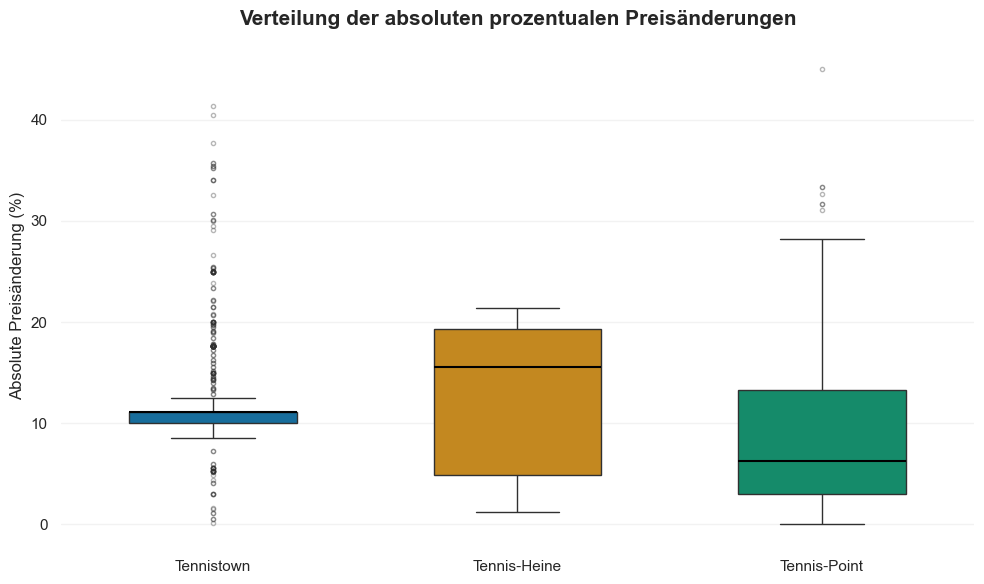

In [15]:
# --- VERTEILUNG DER PREISÄNDERUNGSSTÄRKE VISUALISIEREN ---

# Diagrammfläche vorbereiten
fig, ax = plt.subplots(figsize=(10, 6))

# Boxplot der absoluten prozentualen Preisänderungen erzeugen
sns.boxplot(
    data=df_pairs_with_price_change,
    x='retailer',
    y='absolute_price_change_pct',
    hue='retailer',
    order=retailer_order,
    hue_order=retailer_order,
    palette='colorblind',
    width=0.55,
    showfliers=True,
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.35},
    medianprops={'color': 'black', 'linewidth': 1.5},
    ax=ax
)

# Diagramm beschriften
ax.set_title('Verteilung der absoluten prozentualen Preisänderungen', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Absolute Preisänderung (%)')

# Gitternetz anpassen
ax.grid(axis='y', alpha=0.25)

# Diagramm abschließend formatieren und anzeigen
sns.despine(ax=ax, left=True, bottom=True)
plt.tight_layout()
plt.show()

Bei Tennistown liegen die mittleren 50 % der absoluten prozentualen Preisänderungen eng beieinander. Ein großer Teil der Änderungen bewegt sich damit in einem vergleichsweise schmalen Bereich um etwa 10 bis 11 %. Daneben treten einzelne deutlich kleinere und größere Änderungen auf.

Tennis-Heine weist den höchsten Median und zugleich eine breite Streuung der mittleren Werte auf. Aufgrund der geringen Anzahl zugrunde liegender Preisänderungen sollte die Verteilung jedoch mit Vorsicht interpretiert werden.

Bei Tennis-Point liegt der Median niedriger, die Preisänderungen verteilen sich jedoch über einen deutlich breiteren Bereich als bei Tennistown. Zusätzlich sind einzelne besonders hohe prozentuale Änderungen erkennbar.

Der Boxplot zeigt somit, dass sich nicht nur die Höhe der Mediane, sondern auch die Streuung der Preisänderungen zwischen den Händlern unterscheidet.

## Zeitliche Muster der Preisänderungen untersuchen

Nach der Häufigkeit und Stärke der Preisänderungen wird untersucht, ob sich zeitliche Muster erkennen lassen.

### Preisänderungen innerhalb des Tages und über Nacht vergleichen

Hierfür werden zunächst die beiden unmittelbar vergleichbaren Abrufintervalle gegenübergestellt.

In [16]:
# --- PREISÄNDERUNGEN NACH VERGLEICHSINTERVALL ZUSAMMENFASSEN ---

# Gewünschte Reihenfolge der Vergleichsintervalle festlegen
comparison_interval_order = ['run1 to run2', 'run2 to next run1']

# Vergleichspaare und Preisänderungen je Händler und Intervall zusammenfassen
df_price_change_interval_overview = (
    df_price_pairs
    .groupby(['retailer', 'comparison_interval'], sort=False)
    .agg(
        Comparable_pairs=('price_changed', 'size'),      # Anzahl unmittelbar vergleichbarer Beobachtungspaare bestimmen
        Price_changes=('price_changed', 'sum')           # Beobachtungspaare mit einer Preisänderung zählen
    )
    .reset_index()
    .rename(columns={
        'retailer': 'Retailer',
        'comparison_interval': 'Comparison interval',
        'Comparable_pairs': 'Comparable pairs',
        'Price_changes': 'Price changes'
    })
)

# Anteil der Beobachtungspaare mit einer Preisänderung berechnen
df_price_change_interval_overview['Price change rate (%)'] = (
    df_price_change_interval_overview['Price changes']
    / df_price_change_interval_overview['Comparable pairs']
    * 100
).round(2)

# Händler und Vergleichsintervalle in der festgelegten Reihenfolge anordnen
df_price_change_interval_overview['Retailer'] = pd.Categorical(
    df_price_change_interval_overview['Retailer'],
    categories=retailer_order,
    ordered=True
)

df_price_change_interval_overview['Comparison interval'] = pd.Categorical(
    df_price_change_interval_overview['Comparison interval'],
    categories=comparison_interval_order,
    ordered=True
)

df_price_change_interval_overview = df_price_change_interval_overview.sort_values(['Retailer', 'Comparison interval']).reset_index(drop=True)


print('--- PREISÄNDERUNGEN NACH VERGLEICHSINTERVALL ---')
print('Zeigt vergleichbare Beobachtungspaare und Preisänderungen innerhalb des Tages und über Nacht.\n')

display(df_price_change_interval_overview)

--- PREISÄNDERUNGEN NACH VERGLEICHSINTERVALL ---
Zeigt vergleichbare Beobachtungspaare und Preisänderungen innerhalb des Tages und über Nacht.



,Retailer,Comparison interval,Comparable pairs,Price changes,Price change rate (%)
0,Tennistown,run1 to run2,16579,1610,9.71
1,Tennistown,run2 to next run1,16565,2130,12.86
2,Tennis-Heine,run1 to run2,11560,22,0.19
3,Tennis-Heine,run2 to next run1,11559,2,0.02
4,Tennis-Point,run1 to run2,6332,703,11.10
5,Tennis-Point,run2 to next run1,6387,171,2.68


Die Preisänderungsraten der beiden Vergleichsintervalle werden in einem gruppierten Balkendiagramm gegenübergestellt. Dadurch wird sichtbar, ob Preisänderungen bei den Händlern häufiger innerhalb des Tages oder zwischen dem abendlichen und dem nächsten morgendlichen Abruf auftreten.

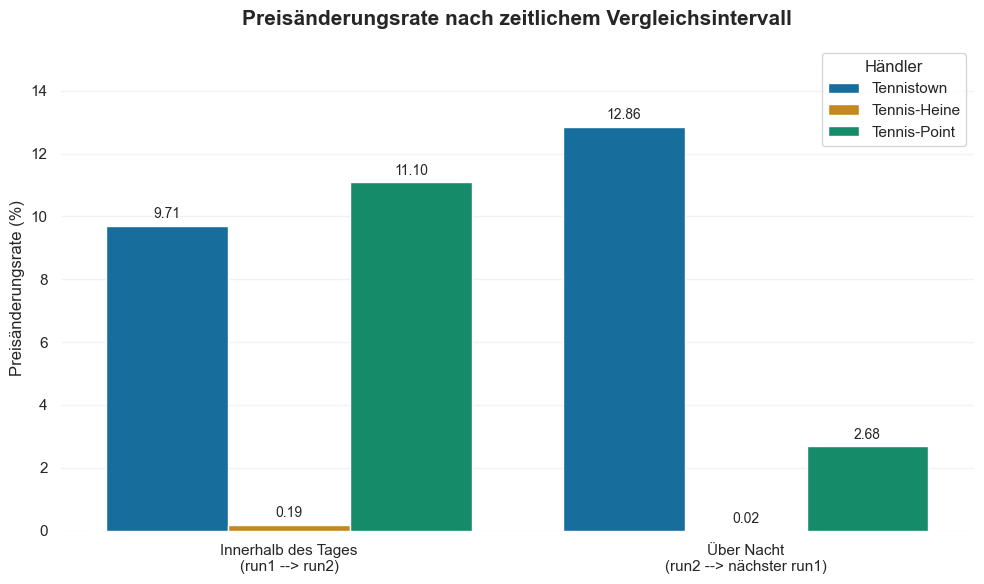

In [17]:
# --- PREISÄNDERUNGSRATEN NACH VERGLEICHSINTERVALL VISUALISIEREN ---

# Diagrammfläche vorbereiten
fig, ax = plt.subplots(figsize=(10, 6))

# Gruppiertes Balkendiagramm erzeugen
sns.barplot(
    data=df_price_change_interval_overview,
    x='Comparison interval',
    y='Price change rate (%)',
    hue='Retailer',
    order=comparison_interval_order,
    hue_order=retailer_order,
    palette='colorblind',
    errorbar=None,
    ax=ax
)

# Prozentwerte über den Balken anzeigen
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# Verständliche Bezeichnungen der Vergleichsintervalle verwenden
comparison_interval_labels = {'run1 to run2': 'Innerhalb des Tages\n(run1 --> run2)', 'run2 to next run1': 'Über Nacht\n(run2 --> nächster run1)'}
ax.set_xticks(range(len(comparison_interval_order)))
ax.set_xticklabels([comparison_interval_labels[interval] for interval in comparison_interval_order])

# Diagramm beschriften
ax.set_title('Preisänderungsrate nach zeitlichem Vergleichsintervall', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Preisänderungsrate (%)')

# Legende und Gitternetz anpassen
ax.legend(title='Händler')
ax.grid(axis='y', alpha=0.25)

# Zusätzlichen Platz für die Werte oberhalb der Balken schaffen
ax.set_ylim(0, df_price_change_interval_overview['Price change rate (%)'].max() * 1.2)

# Diagramm abschließend formatieren und anzeigen
sns.despine(ax=ax, left=True, bottom=True)
plt.tight_layout()
plt.show()

Im beobachtbaren Datenbestand zeigen sich unterschiedliche zeitliche Muster. Bei Tennistown liegt die Preisänderungsrate über Nacht mit 12,86 % über der Rate innerhalb des Tages von 9,71 %. Preisänderungen werden bei diesem Händler somit etwas häufiger zwischen dem abendlichen und dem nächsten morgendlichen Abruf festgestellt.

Bei Tennis-Point zeigt sich das umgekehrte Bild. Innerhalb des Tages liegt die Preisänderungsrate bei 11,10 %, über Nacht dagegen nur bei 2,68 %. Die beobachteten Preisänderungen treten damit überwiegend zwischen dem morgendlichen und dem abendlichen Abruf auf.

Tennis-Heine weist in beiden Intervallen eine sehr geringe Preisänderungsrate auf. Von den wenigen beobachteten Änderungen entfällt jedoch der überwiegende Teil auf das Intervall innerhalb des Tages. Aufgrund des insgesamt weitgehend stabilen Preisniveaus sind die zugehörigen Balken im gemeinsamen Diagramm kaum sichtbar.

> **Hinweis zur zeitlichen Einordnung:** Die Workflows waren planmäßig für 06:00 Uhr und 18:00 Uhr deutscher Sommerzeit angesetzt. Der tatsächliche Start konnte sich jedoch durch die Verfügbarkeit der GitHub-Runner verzögern. Zudem wurden die Produktseiten innerhalb eines Abrufs nacheinander verarbeitet. Während die Abrufe von Tennistown und Tennis-Heine vergleichsweise kurz dauerten (kürzer als 30 Minuten), erstreckten sich Tennis-Point-Abrufe teilweise über mehrere Stunden und konnten bis nach Mitternacht reichen.
>
> Die Bezeichnungen „innerhalb des Tages“ und „über Nacht“ orientieren sich deshalb vereinfachend an der geplanten Abrufreihenfolge. Technisch werden run1 --> run2 desselben geplanten Abruftages und run2 --> run1 des folgenden geplanten Abruftages verglichen. Aufgrund von Verzögerungen können die tatsächlichen Erfassungszeitpunkte von diesen kalendarischen Zeiträumen abweichen. Der genaue Zeitpunkt einer Preisänderung zwischen den beiden Beobachtungen ist nicht bekannt.

### Preisänderungen nach Wochentag vergleichen

Im zweiten Schritt wird explorativ untersucht, ob sich die beobachteten Preisänderungsraten zwischen den Wochentagen unterscheiden.

Für eine eindeutige Zuordnung werden ausschließlich Vergleichspaare zwischen `run1` und `run2` berücksichtigt, bei denen die tatsächlichen Erfassungszeitpunkte beider Produktbeobachtungen auf denselben Kalendertag fallen. Dadurch liegt der gesamte beobachtete Änderungszeitraum innerhalb eines einzelnen Wochentages. Vergleichspaare zwischen `run2` und dem nächsten `run1` werden nicht berücksichtigt, da sich ihr Beobachtungszeitraum über zwei Kalendertage erstreckt. Ebenfalls ausgeschlossen werden `run1`-zu-`run2`-Paare, bei denen der zweite Erfassungszeitpunkt aufgrund eines langen oder verspäteten Abrufs erst nach Mitternacht liegt.

Der genaue Zeitpunkt einer Preisänderung bleibt weiterhin unbekannt. Es kann jedoch festgestellt werden, dass sie zwischen zwei Beobachtungen desselben Kalendertages erfolgt ist.

In [18]:
# --- PREISBEOBACHTUNGEN FÜR DIE WOCHENTAGSAUSWERTUNG AUSWÄHLEN ---

# Vergleichspaare zwischen run1 und run2 desselben geplanten Abruftages kennzeichnen
within_day_pair_mask = df_price_pairs['comparison_interval'].eq('run1 to run2')

# Prüfen, ob beide tatsächlichen Erfassungszeitpunkte auf denselben Kalendertag fallen
same_calendar_day_mask = df_price_pairs['previous_timestamp'].dt.normalize().eq(df_price_pairs['timestamp'].dt.normalize())

# Nur chronologisch korrekte Vergleichspaare innerhalb desselben Kalendertages auswählen
weekday_pair_mask = (
    within_day_pair_mask
    & same_calendar_day_mask
    & df_price_pairs['previous_timestamp'].lt(df_price_pairs['timestamp'])
)

df_price_pairs_with_weekday = df_price_pairs.loc[weekday_pair_mask].copy()

# --- AUSWAHL DER VERGLEICHSPAARE KONTROLLIEREN ---

# Anzahl berücksichtigter und ausgeschlossener run1-zu-run2-Paare je Händler bestimmen
df_weekday_pair_selection_overview = (
    df_price_pairs.loc[within_day_pair_mask]
    .assign(eligible_for_weekday=weekday_pair_mask.loc[within_day_pair_mask])
    .groupby('retailer', sort=False)
    .agg(
        Within_day_pairs=('price_changed', 'size'),                  # Alle vorhandenen run1-zu-run2-Paare zählen
        Eligible_weekday_pairs=('eligible_for_weekday', 'sum')       # Davon eindeutig einem Kalendertag zuordenbare Paare zählen
    )
    .reset_index()
    .rename(columns={
        'retailer': 'Retailer',
        'Within_day_pairs': 'Within-day pairs',
        'Eligible_weekday_pairs': 'Eligible weekday pairs'
    })
)

# Aufgrund eines Datumswechsels oder einer unplausiblen Reihenfolge ausgeschlossene Paare berechnen
df_weekday_pair_selection_overview['Excluded pairs'] = (
    df_weekday_pair_selection_overview['Within-day pairs']
    - df_weekday_pair_selection_overview['Eligible weekday pairs']
)

# Händler in der festgelegten Reihenfolge anordnen
df_weekday_pair_selection_overview = (
    df_weekday_pair_selection_overview
    .set_index('Retailer')
    .reindex(retailer_order)
    .reset_index()
)

print('--- AUSWAHL DER VERGLEICHSPAARE FÜR DIE WOCHENTAGSAUSWERTUNG ---')
print('Zeigt die Anzahl vorhandener und eindeutig einem Kalendertag zuordenbarer run1-zu-run2-Paare je Händler an.\n')

display(df_weekday_pair_selection_overview)

--- AUSWAHL DER VERGLEICHSPAARE FÜR DIE WOCHENTAGSAUSWERTUNG ---
Zeigt die Anzahl vorhandener und eindeutig einem Kalendertag zuordenbarer run1-zu-run2-Paare je Händler an.



,Retailer,Within-day pairs,Eligible weekday pairs,Excluded pairs
0,Tennistown,16579,16579,0
1,Tennis-Heine,11560,11560,0
2,Tennis-Point,6332,5560,772


In [19]:
# --- WOCHENTAG DER VERGLEICHSPAARE BESTIMMEN ---

# Deutsche Bezeichnungen und Reihenfolge der Wochentage festlegen
weekday_labels = {0: 'Montag', 1: 'Dienstag', 2: 'Mittwoch', 3: 'Donnerstag', 4: 'Freitag', 5: 'Samstag', 6: 'Sonntag'}
weekday_order = ['Montag', 'Dienstag', 'Mittwoch', 'Donnerstag', 'Freitag', 'Samstag', 'Sonntag']

# Gemeinsamen Wochentag der beiden Produktbeobachtungen bestimmen
df_price_pairs_with_weekday['comparison_weekday'] = df_price_pairs_with_weekday['timestamp'].dt.dayofweek.map(weekday_labels)

# --- PREISÄNDERUNGEN NACH WOCHENTAG ZUSAMMENFASSEN ---

df_price_change_weekday_overview = (
    df_price_pairs_with_weekday
    .groupby(['retailer', 'comparison_weekday'], sort=False)
    .agg(
        Comparable_pairs=('price_changed', 'size'),      # Vergleichspaare des jeweiligen Wochentages zählen
        Price_changes=('price_changed', 'sum')           # Davon Paare mit einer Preisänderung zählen
    )
    .reset_index()
    .rename(columns={
        'retailer': 'Retailer',
        'comparison_weekday': 'Comparison weekday',
        'Comparable_pairs': 'Comparable pairs',
        'Price_changes': 'Price changes'
    })
)

# Anteil der Beobachtungspaare mit einer Preisänderung berechnen
df_price_change_weekday_overview['Price change rate (%)'] = (
    df_price_change_weekday_overview['Price changes']
    / df_price_change_weekday_overview['Comparable pairs']
    * 100
).round(2)

# Händler und Wochentage in der festgelegten Reihenfolge anordnen
df_price_change_weekday_overview['Retailer'] = pd.Categorical(
    df_price_change_weekday_overview['Retailer'],
    categories=retailer_order,
    ordered=True
)

df_price_change_weekday_overview['Comparison weekday'] = pd.Categorical(
    df_price_change_weekday_overview['Comparison weekday'],
    categories=weekday_order,
    ordered=True
)

df_price_change_weekday_overview = df_price_change_weekday_overview.sort_values(['Retailer', 'Comparison weekday']).reset_index(drop=True)

print('--- PREISÄNDERUNGEN NACH WOCHENTAG ---')
print('Zeigt vergleichbare Beobachtungspaare und Preisänderungen innerhalb desselben Kalendertages nach Wochentag an.\n')

display(df_price_change_weekday_overview)

--- PREISÄNDERUNGEN NACH WOCHENTAG ---
Zeigt vergleichbare Beobachtungspaare und Preisänderungen innerhalb desselben Kalendertages nach Wochentag an.



,Retailer,Comparison weekday,Comparable pairs,Price changes,Price change rate (%)
0,Tennistown,Montag,3452,5,0.14
1,Tennistown,Dienstag,3445,387,11.23
2,Tennistown,Mittwoch,2074,451,21.75
3,Tennistown,Donnerstag,1379,16,1.16
4,Tennistown,Freitag,1379,715,51.85
5,Tennistown,Samstag,1388,12,0.86
6,Tennistown,Sonntag,3462,24,0.69
7,Tennis-Heine,Montag,2408,4,0.17
8,Tennis-Heine,Dienstag,2408,0,0.00
9,Tennis-Heine,Mittwoch,1444,6,0.42


Die Preisänderungsraten werden nach Wochentag und Händler in einem gruppierten Balkendiagramm gegenübergestellt. Die Berechnung als Rate berücksichtigt, dass je Händler und Wochentag unterschiedlich viele vergleichbare Beobachtungspaare vorliegen. Ergebnisse mit einer geringen Anzahl an Vergleichspaaren sind dennoch vorsichtig zu interpretieren.

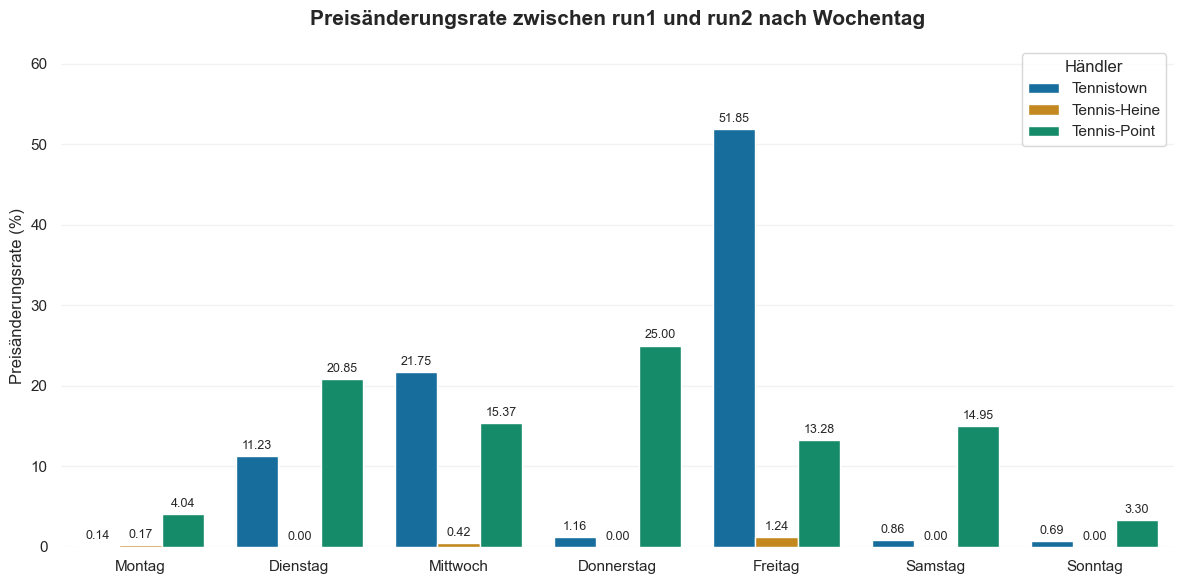

In [20]:
# --- PREISÄNDERUNGSRATEN NACH WOCHENTAG VISUALISIEREN ---

# Diagrammfläche vorbereiten
fig, ax = plt.subplots(figsize=(12, 6))

# Gruppiertes Balkendiagramm erzeugen
sns.barplot(
    data=df_price_change_weekday_overview,
    x='Comparison weekday',
    y='Price change rate (%)',
    hue='Retailer',
    order=weekday_order,
    hue_order=retailer_order,
    palette='colorblind',
    errorbar=None,
    ax=ax
)

# Prozentwerte über den Balken anzeigen
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

# Diagramm beschriften
ax.set_title('Preisänderungsrate zwischen run1 und run2 nach Wochentag', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Preisänderungsrate (%)')

# Legende und Gitternetz anpassen
ax.legend(title='Händler')
ax.grid(axis='y', alpha=0.25)

# Zusätzlichen Platz für die Werte oberhalb der Balken schaffen
ax.set_ylim(0, df_price_change_weekday_overview['Price change rate (%)'].max() * 1.2)

# Diagramm abschließend formatieren und anzeigen
sns.despine(ax=ax, left=True, bottom=True)
plt.tight_layout()
plt.show()

Bei Tennistown konzentrieren sich die innerhalb desselben Kalendertages beobachteten Preisänderungen deutlich auf einzelne Wochentage. Die höchste Preisänderungsrate wird am Freitag mit 51,85 % erreicht, gefolgt von Mittwoch mit 21,75 % und Dienstag mit 11,23 %. An den übrigen Wochentagen liegt die Rate bei höchstens 1,16 %. Im beobachtbaren Datenbestand erfolgen die Preisänderungen zwischen `run1` und `run2` bei Tennistown somit vor allem an Dienstagen, Mittwochen und Freitagen.

Bei Tennis-Point verteilen sich die beobachteten Preisänderungen breiter über die Wochentage. Besonders hohe Raten zeigen sich am Dienstag mit 20,85 % und am Mittwoch mit 15,37 %. Der Wert von 25,00 % am Donnerstag basiert dagegen auf lediglich 40 vergleichbaren Beobachtungspaaren und sollte daher nicht überinterpretiert werden. Auch am Freitag und Samstag liegen die Preisänderungsraten über 13 %, während Montag und Sonntag deutlich niedrigere Werte aufweisen.

Tennis-Heine zeigt unabhängig vom Wochentag nur sehr geringe Preisänderungsraten. Der höchste Wert wird am Freitag mit 1,24 % erreicht. Ein ausgeprägtes Wochentagsmuster ist bei diesem Händler aufgrund der insgesamt wenigen Preisänderungen nicht erkennbar.

Insgesamt zeigt sich kein einheitliches Wochentagsmuster über alle drei Händler. Die Ergebnisse sind als explorative Beschreibung der verfügbaren Vergleichspaare zu verstehen. Die einzelnen Wochentage beruhen auf unterschiedlich vielen Erhebungstagen und Beobachtungspaaren. Insbesondere bei Tennis-Point wird die Vergleichbarkeit zusätzlich durch die vollständig und teilweise unvollständigen Abrufe eingeschränkt. Aus den beobachteten Unterschieden lässt sich daher kein dauerhaftes Preisänderungsschema ableiten.

## Auffällige Preisverläufe ausgewählter Produktvarianten darstellen

Abschließend werden ausgewählte Produktvarianten mit besonders häufigen Preisänderungen betrachtet. Hierfür wird je Händler die Produktvariante mit der höchsten Anzahl beobachteter Preisänderungen ausgewählt. Liegt dabei ein Gleichstand vor, wird die Variante mit der größten einzelnen absoluten Preisänderung berücksichtigt.

Die Auswahl dient der anschaulichen Darstellung auffälliger Preisverläufe.

In [21]:
# --- PRODUKTVARIANTEN NACH DER ANZAHL IHRER PREISÄNDERUNGEN EINORDNEN ---

# Anzahl und größte absolute Preisänderung je Produktvariante zusammenfassen
df_product_variant_change_ranking = (
    df_pairs_with_price_change
    .groupby(product_variant_columns, sort=False)
    .agg(
        Product=('name', 'first'),                                             # Produktnamen übernehmen
        Category=('category', 'first'),                                        # Produktkategorie übernehmen
        Price_changes=('price_changed', 'size'),                               # Anzahl beobachteter Preisänderungen zählen
        Maximum_absolute_change_eur=('absolute_price_change_eur', 'max')       # Größte einzelne absolute Preisänderung bestimmen
    )
    .reset_index()
)

# Produktvarianten zuerst nach Anzahl und anschließend nach Stärke der Preisänderungen sortieren
df_product_variant_change_ranking = df_product_variant_change_ranking.sort_values(
    ['retailer', 'Price_changes', 'Maximum_absolute_change_eur'],
    ascending=[True, False, False]
)

# Je Händler die höchstplatzierte Produktvariante auswählen
df_selected_product_variants = (
    df_product_variant_change_ranking
    .groupby('retailer', sort=False)
    .head(1)
    .copy()
)

# Händler in der festgelegten Reihenfolge anordnen
df_selected_product_variants = (
    df_selected_product_variants
    .set_index('retailer')
    .reindex(retailer_order)
    .reset_index()
)

In [22]:
# --- PREISBEOBACHTUNGEN DER AUSGEWÄHLTEN PRODUKTVARIANTEN ZUSAMMENFÜHREN ---

# Alle tatsächlich vorhandenen Beobachtungen der ausgewählten Produktvarianten übernehmen
df_selected_price_history = (
    df_price_history
    .merge(
        df_selected_product_variants[product_variant_columns],
        on=product_variant_columns,
        how='inner'
    )
    .sort_values(product_variant_columns + ['run_date', 'run_order'])
    .reset_index(drop=True)
)

# Beobachtungsumfang sowie niedrigsten und höchsten Preis je ausgewählter Produktvariante bestimmen
df_selected_price_range = (
    df_selected_price_history
    .groupby(product_variant_columns, sort=False)
    .agg(
        Observations=('current_price', 'size'),
        Minimum_observed_price=('current_price', 'min'),
        Maximum_observed_price=('current_price', 'max')
    )
    .reset_index()
)

# Preisumfang mit den Auswahlkennzahlen verbinden
df_selected_product_variants = df_selected_product_variants.merge(df_selected_price_range, on=product_variant_columns, how='left')

# Übersicht für die Ausgabe vorbereiten
df_selected_product_overview = (
    df_selected_product_variants[[
        'retailer',
        'Product',
        'Category',
        'reference_variant',
        'Observations',
        'Price_changes',
        'Minimum_observed_price',
        'Maximum_observed_price',
        'Maximum_absolute_change_eur'
    ]]
    .rename(columns={
        'retailer': 'Retailer',
        'reference_variant': 'Reference variant',
        'Minimum_observed_price': 'Minimum observed price (€)',
        'Maximum_observed_price': 'Maximum observed price (€)',
        'Maximum_absolute_change_eur': 'Maximum absolute change (€)'
    })
)

# Preisangaben auf zwei Nachkommastellen runden
df_selected_product_overview = df_selected_product_overview.round({
    'Minimum observed price (€)': 2,
    'Maximum observed price (€)': 2,
    'Maximum absolute change (€)': 2
})

print('--- AUSGEWÄHLTE PRODUKTVARIANTEN MIT AUFFÄLLIGEN PREISVERLÄUFEN ---')
print('Zeigt je Händler die Produktvariante mit den meisten beobachteten Preisänderungen an.\n')

display(df_selected_product_overview)

--- AUSGEWÄHLTE PRODUKTVARIANTEN MIT AUFFÄLLIGEN PREISVERLÄUFEN ---
Zeigt je Händler die Produktvariante mit den meisten beobachteten Preisänderungen an.



,Retailer,Product,Category,Reference variant,Observations,Price_changes,Minimum observed price (€),Maximum observed price (€),Maximum absolute change (€)
0,Tennistown,Head Tennisschläger Squared 100in/295g/Turnier...,rackets,L2,57,13,167.84,260.00,92.16
1,Tennis-Heine,Wilson Blade 98 16x19 V10 Tennisschläger,rackets,L2,57,1,227.80,289.90,62.10
2,Tennis-Point,Speed MP L 2026 Turnierschläger unbesaitet,rackets,L2,43,8,159.95,174.95,13.00


Die Preisverläufe der drei ausgewählten Produktvarianten werden anhand der tatsächlich vorhandenen Beobachtungen dargestellt. Linien werden ausschließlich zwischen unmittelbar vergleichbaren Beobachtungen gezogen. Liegt zwischen zwei Beobachtungen eine Erfassungslücke, wird der Preisverlauf an dieser Stelle unterbrochen.

In [23]:
# --- ZUSAMMENHÄNGENDE ABSCHNITTE DER PREISVERLÄUFE BESTIMMEN ---

# Bei der ersten Beobachtung und nach jeder Erfassungslücke einen neuen Abschnitt beginnen
df_selected_price_history['price_segment'] = (
    df_selected_price_history
    .groupby(product_variant_columns, sort=False)['comparison_interval']
    .transform(lambda values: values.isna().cumsum())
)

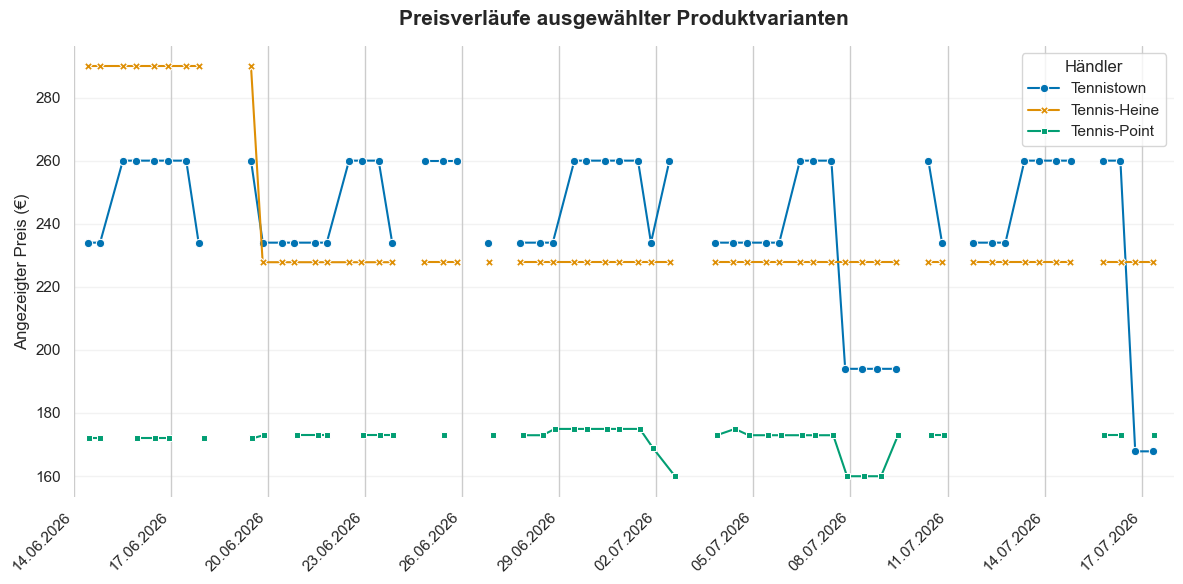

In [24]:
# --- PREISVERLÄUFE DER AUSGEWÄHLTEN PRODUKTVARIANTEN VISUALISIEREN ---

# Ersten und letzten Kalendertag des Erhebungszeitraums bestimmen
price_start_date = df_price_history['run_date'].min()
price_end_date = df_price_history['run_date'].max()

# Datumsmarkierungen im Abstand von drei Tagen ab dem ersten Erhebungstag erzeugen
price_tick_positions = pd.date_range(start=price_start_date, end=price_end_date, freq='3D').tolist()

# Letzten Erhebungstag zusätzlich anzeigen
if price_tick_positions[-1] != price_end_date:
    price_tick_positions.append(price_end_date)

# Datumsmarkierungen für die Achse formatieren
price_tick_labels = [timestamp.strftime('%d.%m.%Y') for timestamp in price_tick_positions]

# Diagrammfläche vorbereiten
fig, ax = plt.subplots(figsize=(12, 6))

# Preisverläufe darstellen; getrennte Abschnitte verhindern das Verbinden über Erfassungslücken
sns.lineplot(
    data=df_selected_price_history,
    x='timestamp',
    y='current_price',
    hue='retailer',
    style='retailer',
    units='price_segment',
    estimator=None,
    hue_order=retailer_order,
    style_order=retailer_order,
    palette='colorblind',
    markers=True,
    dashes=False,
    linewidth=1.5,
    ax=ax
)

# Diagramm beschriften
ax.set_title('Preisverläufe ausgewählter Produktvarianten', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Angezeigter Preis (€)')

# Legende und Gitternetz anpassen
ax.legend(title='Händler')
ax.grid(axis='y', alpha=0.25)

# Datumsmarkierungen und Zeitbereich einheitlich festlegen
ax.set_xticks(price_tick_positions)
ax.set_xticklabels(price_tick_labels, rotation=45, ha='right')
ax.set_xlim(price_start_date, price_end_date + pd.Timedelta(days=1))

# Diagramm abschließend formatieren und anzeigen
sns.despine(ax=ax, left=True, bottom=True)
plt.tight_layout()
plt.show()

Die ausgewählte Tennistown-Produktvariante weist mit 13 festgestellten Preisänderungen den dynamischsten Verlauf der drei Fallbeispiele auf. Der Preis wechselt mehrfach zwischen 234,00 € und 260,00 €. Zusätzlich werden einzelne stärkere Preissenkungen auf 194,00 € beziehungsweise 167,84 € beobachtet. Die größte einzelne absolute Preisänderung beträgt 92,16 €. Der Verlauf zeigt damit wiederholte Preiswechsel und keine kontinuierliche Entwicklung in nur eine Richtung.

Bei der ausgewählten Tennis-Point-Produktvariante werden acht Preisänderungen festgestellt. Die beobachteten Preise bewegen sich in einem vergleichsweise engen Bereich zwischen 159,95 € und 174,95 €. Innerhalb dieses Bereichs treten wiederholt kleinere Preissteigerungen und Preissenkungen auf. Die größte einzelne absolute Änderung beträgt 13,00 €.

Die ausgewählte Tennis-Heine-Produktvariante zeigt lediglich eine Preisänderung. Der Preis sinkt dabei von 289,90 € auf 227,80 € und bleibt ansonsten weitgehend stabil. Da mehrere Tennis-Heine-Varianten dieselbe geringe Anzahl an Preisänderungen aufweisen, wurde dieses Beispiel aufgrund der größten einzelnen absoluten Änderung von 62,10 € ausgewählt.

Die Fallbeispiele verdeutlichen unterschiedliche Formen der beobachteten Preisdynamik: wiederholte stärkere Preiswechsel bei Tennistown, mehrere kleinere Schwankungen bei Tennis-Point und eine einzelne deutliche Preissenkung bei Tennis-Heine. Da gezielt besonders auffällige Produktvarianten ausgewählt wurden, lassen sich diese Verläufe nicht auf das gesamte Sortiment der jeweiligen Händler übertragen. Die Markierungen zeigen ausschließlich tatsächlich vorhandene Produktbeobachtungen; Erfassungslücken werden nicht ergänzt.